In [2]:
import random
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)

from imblearn.over_sampling import ADASYN

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential

import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [3]:
data = pd.read_csv("data.csv")

print(f"Shape: {data.shape}")
data.head()

Shape: (1000, 15)


,id,rpm,motor_power,noise_db,outlet_pressure_bar,air_flow,outlet_temp,wpump_outlet_press,water_flow,gaccz,haccz,bearings,wpump,radiator,exvalve
0,1,499,1405.842858,40.840517,1.000,308.289879,78.554715,2.960632,59.085059,2.649801,2.962484,Ok,Ok,Clean,Clean
1,2,513,1457.370092,40.484226,1.081,307.833736,76.902822,2.536711,59.161939,2.669423,2.938135,Ok,Ok,Clean,Clean
2,3,495,1582.249959,40.918572,1.369,307.377593,77.547021,2.112789,59.041939,2.772009,2.991878,Ok,Ok,Clean,Clean
3,4,480,1712.466820,40.450953,1.691,306.975248,80.059949,2.087534,59.037176,2.876056,3.096158,Ok,Ok,Clean,Clean
4,5,498,1766.035170,41.233739,1.731,306.832132,79.130424,2.338877,59.164154,2.849451,3.059417,Ok,Ok,Clean,Clean


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1000 non-null   int64  
 1   rpm                  1000 non-null   int64  
 2   motor_power          1000 non-null   float64
 3   noise_db             1000 non-null   float64
 4   outlet_pressure_bar  1000 non-null   float64
 5   air_flow             1000 non-null   float64
 6   outlet_temp          1000 non-null   float64
 7   wpump_outlet_press   1000 non-null   float64
 8   water_flow           1000 non-null   float64
 9   gaccz                1000 non-null   float64
 10  haccz                1000 non-null   float64
 11  bearings             1000 non-null   str    
 12  wpump                1000 non-null   str    
 13  radiator             1000 non-null   str    
 14  exvalve              1000 non-null   str    
dtypes: float64(9), int64(2), str(4)
memory usage: 117.

In [5]:
data.describe()

,id,rpm,motor_power,noise_db,outlet_pressure_bar,air_flow,outlet_temp,wpump_outlet_press,water_flow,gaccz,haccz
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,1499.516000,6984.877371,53.412121,4.054049,754.673930,118.855110,2.799610,53.708176,3.923073,3.495037
std,288.819436,707.681915,4269.277571,8.055363,1.862761,442.743491,19.120181,0.455274,6.587259,1.610130,0.817667
min,1.000000,480.000000,1402.424603,39.879017,1.000000,95.098952,76.902822,1.834533,38.570791,1.730301,2.329267
25%,250.750000,988.750000,3559.437042,46.490976,2.443750,305.388152,104.731080,2.448208,50.459245,2.576739,2.802622
50%,500.500000,1500.000000,5906.662534,52.708480,4.038000,608.626411,118.275842,2.780492,58.112667,3.610639,3.339698
75%,750.250000,2010.000000,9636.002782,60.158248,5.600250,1193.266273,132.850790,3.092101,58.552897,5.081960,4.071874
max,1000.000000,2520.000000,19454.559080,74.401986,8.664000,1539.911634,172.711382,4.295136,59.174992,9.209166,6.107852


In [6]:
label_columns = ["bearings", "wpump", "radiator", "exvalve"]
feature_columns = [c for c in data.columns if c not in label_columns + ["id"]]

TARGETS = {
    "bearings": {
        "label_map": {"Ok": 0, "Noisy": 1},
        "class_names": ["Ok", "Noisy"],
    },
    "wpump": {
        "label_map": {"Ok": 0, "Noisy": 1},
        "class_names": ["Ok", "Noisy"],
    },
    "radiator": {
        "label_map": {"Clean": 0, "Dirty": 1},
        "class_names": ["Clean", "Dirty"],
    },
    "exvalve": {
        "label_map": {"Clean": 0, "Dirty": 1},
        "class_names": ["Clean", "Dirty"],
    },
}

print("Feature columns:", feature_columns)
print(f"Total features: {len(feature_columns)}")
print("\nClass distribution per target:")
for target in label_columns:
    print(f"  {target}: {data[target].value_counts().to_dict()}")

Feature columns: ['rpm', 'motor_power', 'noise_db', 'outlet_pressure_bar', 'air_flow', 'outlet_temp', 'wpump_outlet_press', 'water_flow', 'gaccz', 'haccz']
Total features: 10

Class distribution per target:
  bearings: {'Ok': 800, 'Noisy': 200}
  wpump: {'Ok': 800, 'Noisy': 200}
  radiator: {'Clean': 800, 'Dirty': 200}
  exvalve: {'Clean': 800, 'Dirty': 200}



  MODEL: BEARINGS

Train : {0: 512, 1: 128}
Val   : {0: 128, 1: 32}
Test  : {0: 160, 1: 40}
After ADASYN: {1: 524, 0: 512}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_features (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4662 - loss: 0.7047 - val_accuracy: 0.4688 - val_loss: 0.6982
Epoch 2/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5106 - loss: 0.6931 - val_accuracy: 0.4688 - val_loss: 0.7006
Epoch 3/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5792 - loss: 0.6749 - val_accuracy: 0.5250 - val_loss: 0.6925
Epoch 4/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6014 - loss: 0.6672 - val_accuracy: 0.6250 - val_loss: 0.6756
Epoch 5/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6120 - loss: 0.6614 - val_accuracy: 0.6250 - val_loss: 0.6697
Epoch 6/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6602 - loss: 0.6503 - val_accuracy: 0.6125 - val_loss: 0.6633
Epoch 7/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6680 - loss: 0.6433 - val_accuracy: 0.6313 - val_loss: 0.6557
Epoch 8/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6979 - loss: 0.6180 - val_accuracy: 0.6812 - 

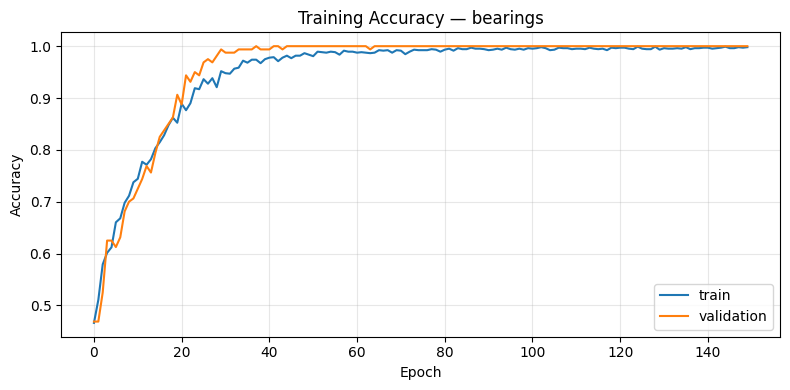


--- Metrics ---
  accuracy: 0.9900
  balanced_accuracy: 0.9750
  f1_fault: 0.9744
  roc_auc: 1.0000
              precision    recall  f1-score   support

          Ok       0.99      1.00      0.99       160
       Noisy       1.00      0.95      0.97        40

    accuracy                           0.99       200
   macro avg       0.99      0.97      0.98       200
weighted avg       0.99      0.99      0.99       200



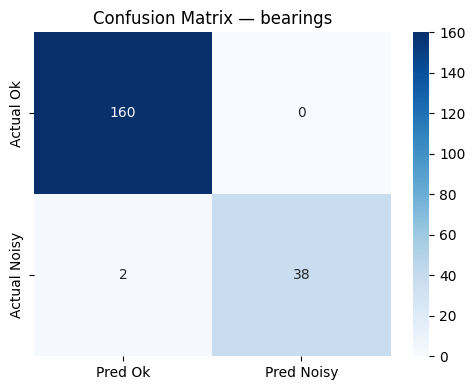

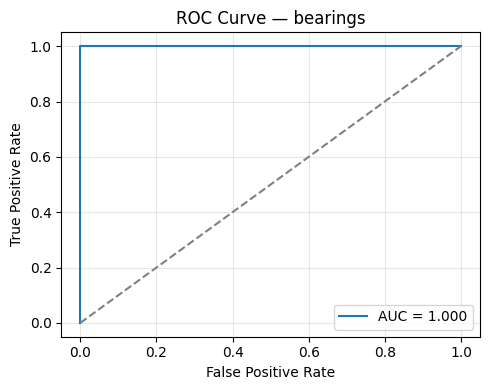

  0%|          | 0/100 [00:00<?, ?it/s]

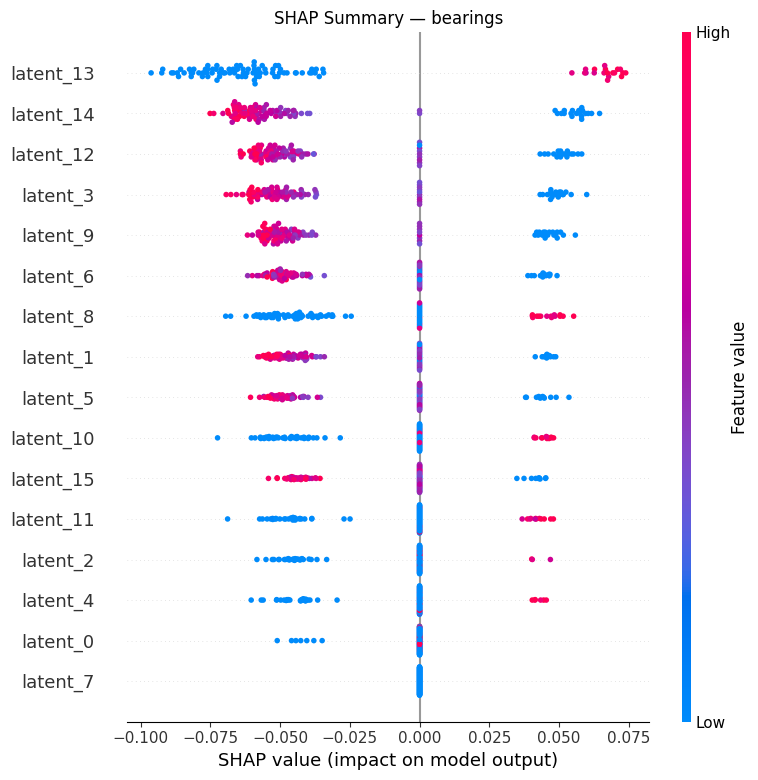

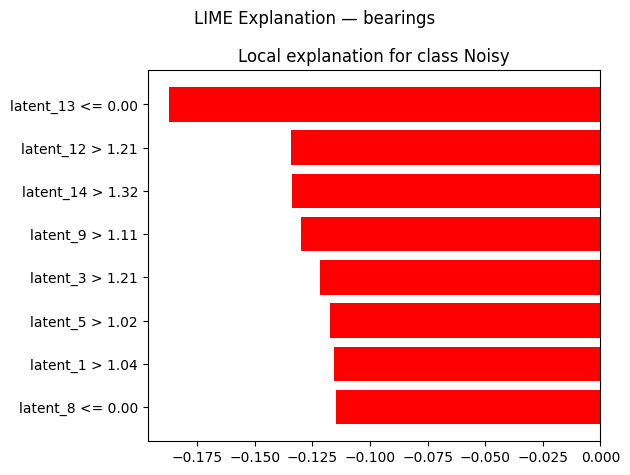

Saved: models/hybrid_model_bearings.pkl

  MODEL: WPUMP

Train : {0: 512, 1: 128}
Val   : {0: 128, 1: 32}
Test  : {0: 160, 1: 40}
After ADASYN: {1: 517, 0: 512}


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_features (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5296 - loss: 0.6913 - val_accuracy: 0.2313 - val_loss: 0.7194
Epoch 2/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5782 - loss: 0.6754 - val_accuracy: 0.4750 - val_loss: 0.7089
Epoch 3/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5928 - loss: 0.6631 - val_accuracy: 0.5688 - val_loss: 0.6973
Epoch 4/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6511 - loss: 0.6492 - val_accuracy: 0.5938 - val_loss: 0.6940
Epoch 5/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6463 - loss: 0.6378 - val_accuracy: 0.6375 - val_loss: 0.6844
Epoch 6/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7094 - loss: 0.6154 - val_accuracy: 0.6938 - val_loss: 0.6508
Epoch 7/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6754 - loss: 0.6148 - val_accuracy: 0.6875 - val_loss: 0.6312
Epoch 8/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6900 - loss: 0.5924 - val_accuracy: 0.6875 - 

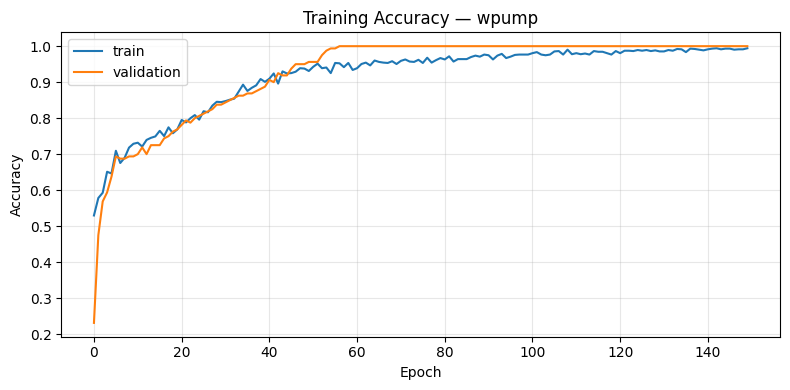


--- Metrics ---
  accuracy: 1.0000
  balanced_accuracy: 1.0000
  f1_fault: 1.0000
  roc_auc: 1.0000
              precision    recall  f1-score   support

          Ok       1.00      1.00      1.00       160
       Noisy       1.00      1.00      1.00        40

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



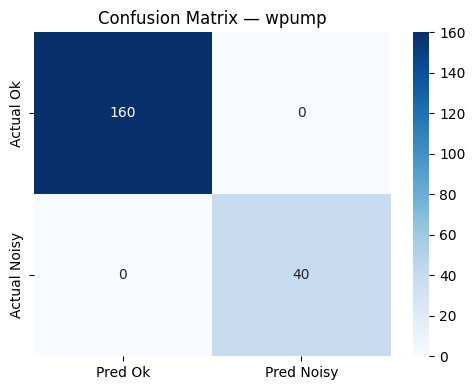

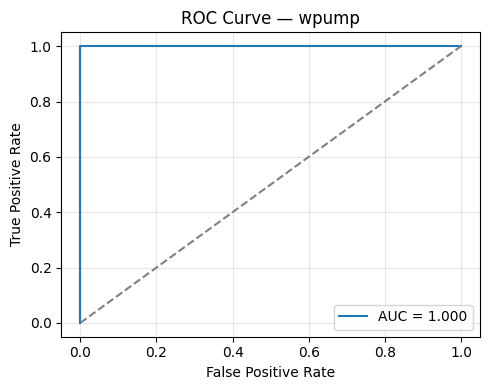

  0%|          | 0/100 [00:00<?, ?it/s]

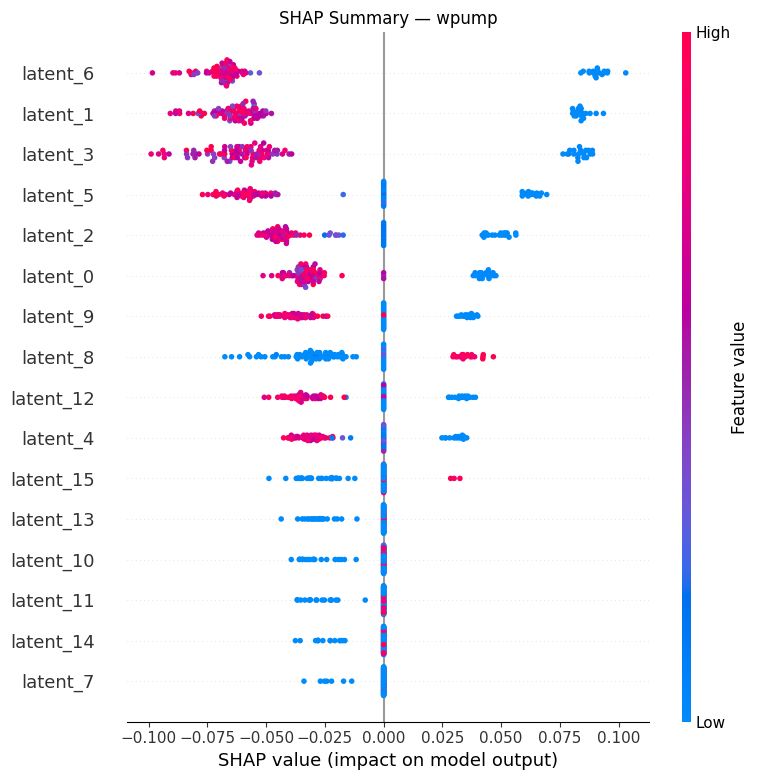

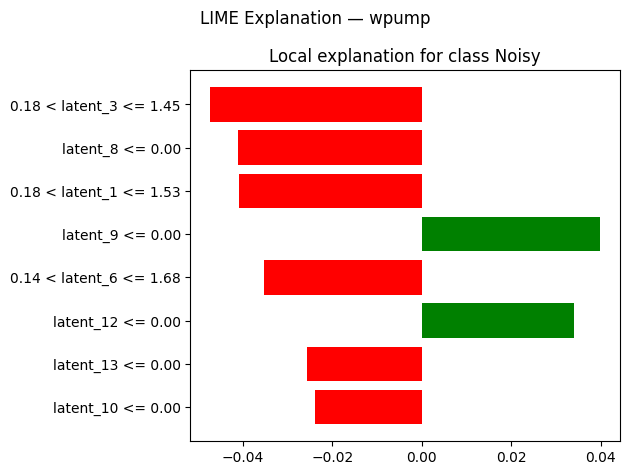

Saved: models/hybrid_model_wpump.pkl

  MODEL: RADIATOR

Train : {0: 512, 1: 128}
Val   : {0: 128, 1: 32}
Test  : {0: 160, 1: 40}
After ADASYN: {0: 512, 1: 512}


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_features (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6279 - loss: 0.6561 - val_accuracy: 0.7437 - val_loss: 0.6539
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6758 - loss: 0.6293 - val_accuracy: 0.8000 - val_loss: 0.6249
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7393 - loss: 0.5884 - val_accuracy: 0.8750 - val_loss: 0.5768
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8008 - loss: 0.5487 - val_accuracy: 0.8938 - val_loss: 0.5144
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8496 - loss: 0.4810 - val_accuracy: 0.8938 - val_loss: 0.4648
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8711 - loss: 0.4377 - val_accuracy: 0.9000 - val_loss: 0.4063
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8887 - loss: 0.3824 - val_accuracy: 0.9000 - val_loss: 0.3575
Epoch 8/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9082 - loss: 0.3207 - val_accuracy: 0.9000 - 

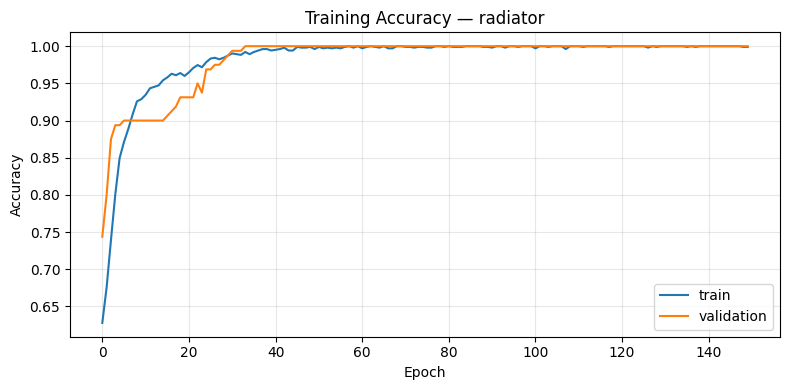


--- Metrics ---
  accuracy: 1.0000
  balanced_accuracy: 1.0000
  f1_fault: 1.0000
  roc_auc: 1.0000
              precision    recall  f1-score   support

       Clean       1.00      1.00      1.00       160
       Dirty       1.00      1.00      1.00        40

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



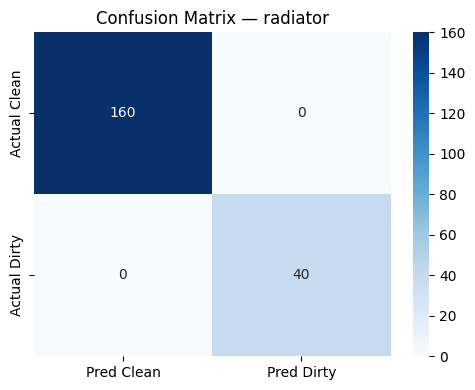

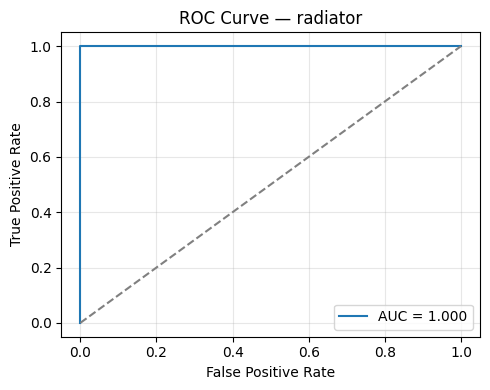

  0%|          | 0/100 [00:00<?, ?it/s]

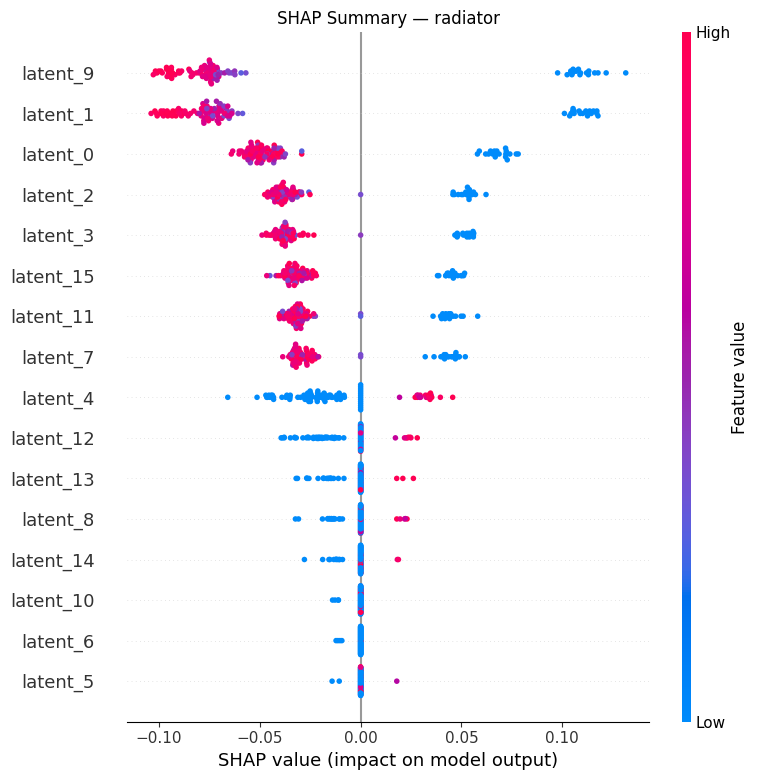

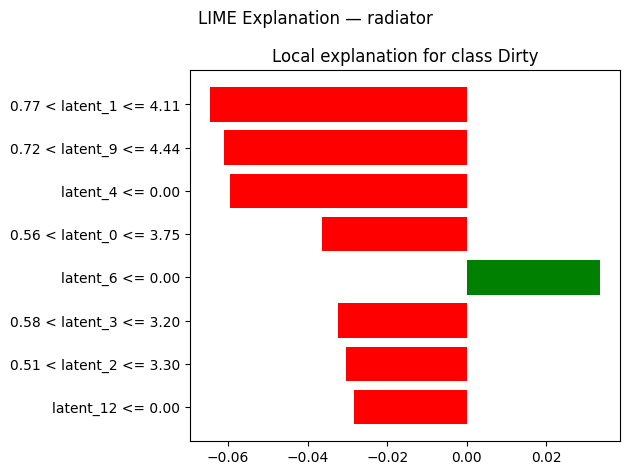

Saved: models/hybrid_model_radiator.pkl

  MODEL: EXVALVE

Train : {0: 512, 1: 128}
Val   : {0: 128, 1: 32}
Test  : {0: 160, 1: 40}
After ADASYN: {1: 521, 0: 512}


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_features (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5808 - loss: 0.6779 - val_accuracy: 0.7312 - val_loss: 0.6441
Epoch 2/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6699 - loss: 0.6421 - val_accuracy: 0.7625 - val_loss: 0.6000
Epoch 3/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7531 - loss: 0.6024 - val_accuracy: 0.7563 - val_loss: 0.5584
Epoch 4/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7890 - loss: 0.5606 - val_accuracy: 0.7563 - val_loss: 0.5204
Epoch 5/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7890 - loss: 0.5255 - val_accuracy: 0.7625 - val_loss: 0.4918
Epoch 6/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7880 - loss: 0.4932 - val_accuracy: 0.7625 - val_loss: 0.4626
Epoch 7/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8180 - loss: 0.4534 - val_accuracy: 0.7625 - val_loss: 0.4414
Epoch 8/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8267 - loss: 0.4226 - val_accuracy: 0.7750 - v

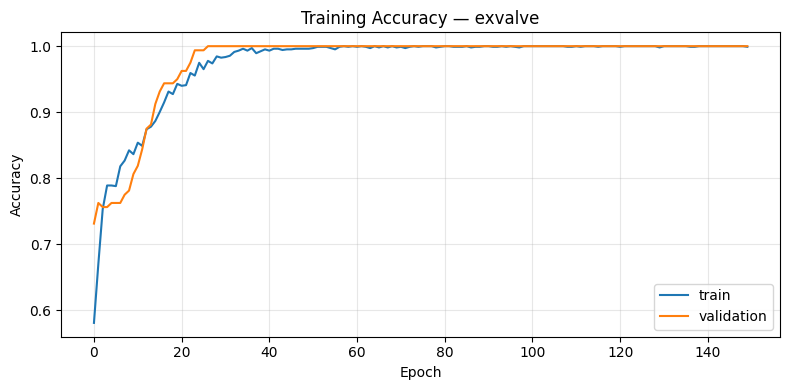


--- Metrics ---
  accuracy: 1.0000
  balanced_accuracy: 1.0000
  f1_fault: 1.0000
  roc_auc: 1.0000
              precision    recall  f1-score   support

       Clean       1.00      1.00      1.00       160
       Dirty       1.00      1.00      1.00        40

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



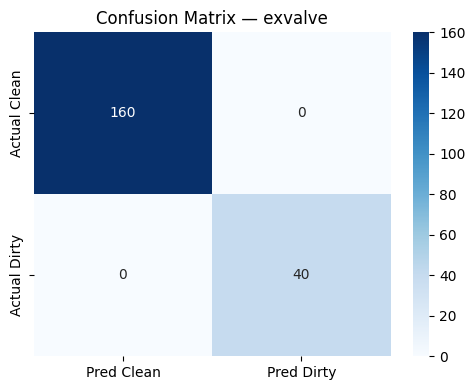

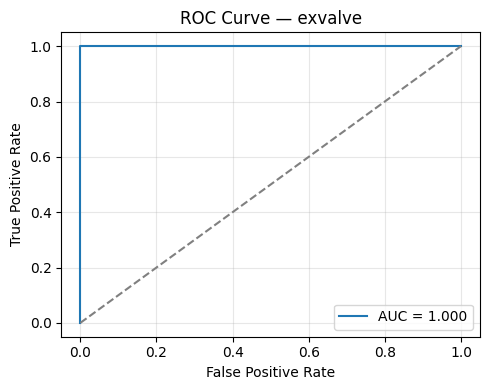

  0%|          | 0/100 [00:00<?, ?it/s]

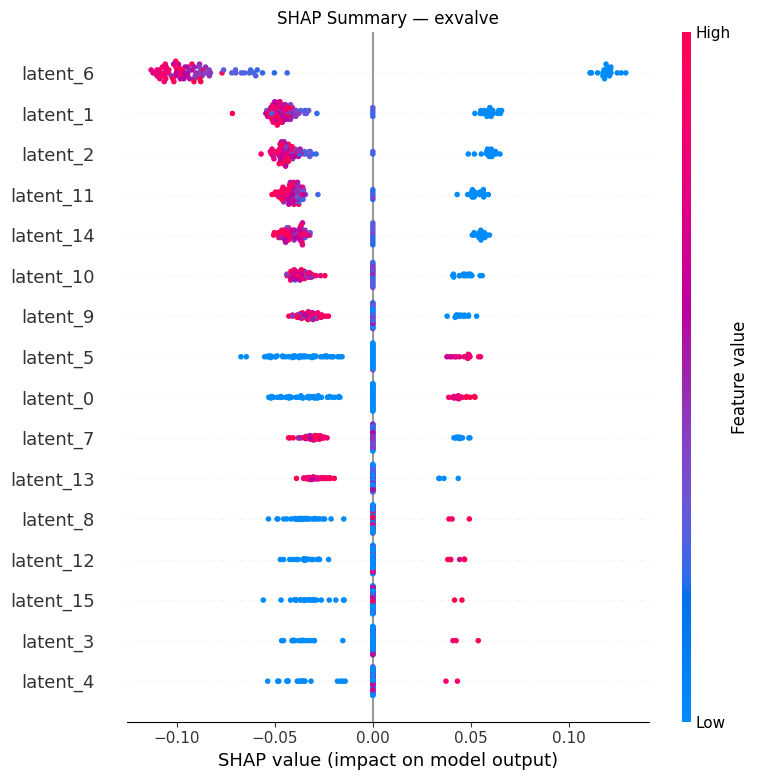

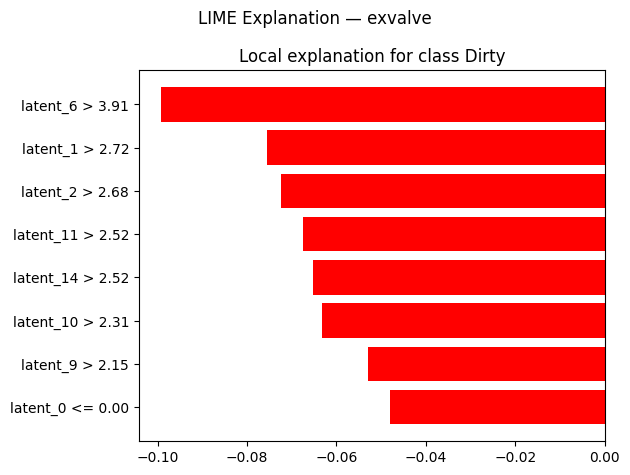

Saved: models/hybrid_model_exvalve.pkl


In [7]:
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

all_metrics = {}

for target_column, config in TARGETS.items():
    print(f"\n{'='*60}")
    print(f"  MODEL: {target_column.upper()}")
    print(f"{'='*60}\n")

    label_map = config["label_map"]
    class_names = config["class_names"]

    X = data[feature_columns].copy()
    y = data[target_column].map(label_map)

    # --- Split ---
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
    X_train_raw, X_val_raw, y_train, y_val = train_test_split(
        X_train_raw, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
    )

    print(f"Train : {y_train.value_counts().to_dict()}")
    print(f"Val   : {y_val.value_counts().to_dict()}")
    print(f"Test  : {y_test.value_counts().to_dict()}")

    # --- Scale ---
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_val   = scaler.transform(X_val_raw)
    X_test  = scaler.transform(X_test_raw)

    # --- ADASYN ---
    adasyn = ADASYN(random_state=RANDOM_STATE)
    X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)
    print(f"After ADASYN: {pd.Series(y_train_res).value_counts().to_dict()}")

    # --- DNN ---
    tf.random.set_seed(RANDOM_STATE)
    model = Sequential([
        Input(shape=(X_train_res.shape[1],)),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(16, activation="relu", name="latent_features"),
        Dropout(0.3),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    model.summary()

    early_stop = EarlyStopping(
        monitor="val_loss", patience=20, restore_best_weights=True
    )
    history = model.fit(
        X_train_res, y_train_res,
        epochs=150,
        batch_size=64,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        shuffle=True,
        verbose=1,
    )

    # Training history
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="validation")
    plt.title(f"Training Accuracy — {target_column}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Feature extractor ---
    feature_extractor = tf.keras.Model(
        inputs=model.inputs,
        outputs=model.get_layer("latent_features").output,
    )
    train_features_res = feature_extractor.predict(X_train_res, verbose=0)
    val_features       = feature_extractor.predict(X_val, verbose=0)
    test_features      = feature_extractor.predict(X_test, verbose=0)

    # --- SVM ---
    svm = SVC(
        kernel="rbf", C=10, gamma="scale",
        class_weight="balanced", probability=True,
        random_state=RANDOM_STATE,
    )
    svm.fit(train_features_res, y_train_res)

    # --- Evaluation ---
    pred   = svm.predict(test_features)
    y_prob = svm.predict_proba(test_features)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "f1_fault": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
    }
    all_metrics[target_column] = metrics

    print("\n--- Metrics ---")
    for name, value in metrics.items():
        print(f"  {name}: {value:.4f}")
    print(classification_report(y_test, pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=[f"Pred {c}" for c in class_names],
        yticklabels=[f"Actual {c}" for c in class_names],
    )
    plt.title(f"Confusion Matrix — {target_column}")
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title(f"ROC Curve — {target_column}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- SHAP ---
    latent_names = [f"latent_{i}" for i in range(train_features_res.shape[1])]
    shap_explainer = shap.KernelExplainer(
        svm.predict,
        shap.sample(train_features_res, 100, random_state=RANDOM_STATE),
    )
    shap_values = shap_explainer.shap_values(test_features[:100])
    shap.summary_plot(shap_values, test_features[:100], feature_names=latent_names, show=False)
    plt.title(f"SHAP Summary — {target_column}")
    plt.tight_layout()
    plt.show()

    # --- LIME ---
    lime_explainer = LimeTabularExplainer(
        train_features_res,
        feature_names=latent_names,
        class_names=class_names,
        mode="classification",
        discretize_continuous=True,
        random_state=RANDOM_STATE,
    )
    lime_exp = lime_explainer.explain_instance(
        test_features[0], svm.predict_proba, num_features=8
    )
    fig = lime_exp.as_pyplot_figure()
    fig.suptitle(f"LIME Explanation — {target_column}")
    plt.tight_layout()
    plt.show()

    # --- Save ---
    model.save(models_dir / f"dnn_{target_column}.keras")
    feature_extractor.save(models_dir / f"dnn_extractor_{target_column}.keras")
    joblib.dump(
        {
            "scaler": scaler,
            "svm": svm,
            "feature_columns": feature_columns,
            "target_column": target_column,
            "label_mapping": label_map,
            "class_names": class_names,
            "metrics": metrics,
        },
        models_dir / f"hybrid_model_{target_column}.pkl",
    )
    print(f"Saved: models/hybrid_model_{target_column}.pkl")


  RINGKASAN METRICS SEMUA KOMPONEN
          Accuracy  Balanced Acc  F1 Fault  ROC-AUC
bearings      0.99         0.975    0.9744      1.0
wpump         1.00         1.000    1.0000      1.0
radiator      1.00         1.000    1.0000      1.0
exvalve       1.00         1.000    1.0000      1.0


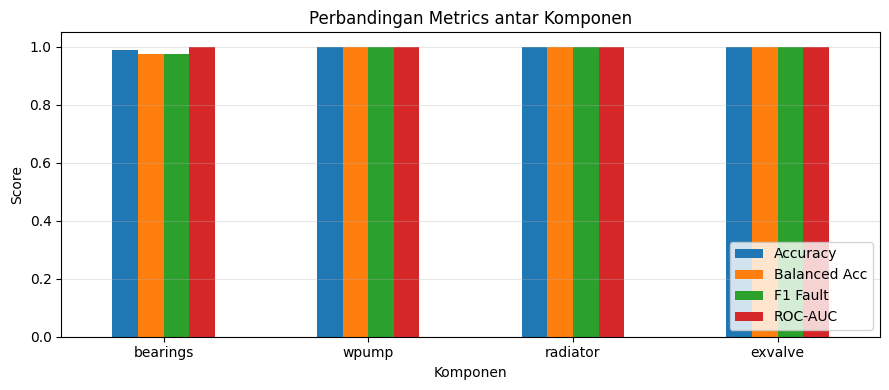

In [8]:
print("\n" + "="*60)
print("  RINGKASAN METRICS SEMUA KOMPONEN")
print("="*60)

summary_df = pd.DataFrame(all_metrics).T
summary_df.columns = ["Accuracy", "Balanced Acc", "F1 Fault", "ROC-AUC"]
print(summary_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
summary_df.round(4).plot(kind="bar", ax=ax, ylim=(0, 1.05), rot=0)
ax.set_title("Perbandingan Metrics antar Komponen")
ax.set_xlabel("Komponen")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Kesimpulan Pipeline
#
# Dataset  : data.csv — 1000 baris, 10 sensor, 4 label komponen
# Sensor   : rpm, motor_power, noise_db, outlet_pressure_bar, air_flow,
#            outlet_temp, wpump_outlet_press, water_flow, gaccz, haccz
# Target   : bearings, wpump, radiator, exvalve  (acmotor dihapus: semua Stable)
# Metode   : DNN (feature extractor 16-dim) + SVM RBF (classifier)
#
# Pipeline per komponen:
# 1. Sensor dipilih berbasis domain knowledge (10 dari 20 sensor asli).
# 2. Split stratified: 64% train / 16% validation / 20% test.
# 3. MinMaxScaler hanya fit pada data train (mencegah data leakage).
# 4. ADASYN hanya pada train set untuk menangani class imbalance.
# 5. DNN mengekstrak 16 fitur laten dari 10 sensor.
# 6. SVM RBF mengklasifikasikan fitur laten.
# 7. Evaluasi: accuracy, balanced accuracy, F1 fault, ROC-AUC.
# 8. SHAP (global) + LIME (lokal) untuk explainability.
# 9. Setiap komponen disimpan sebagai file model terpisah di folder models/.